# 전처리 설계 — 모델 규격에서 역산한 실측 근거 (2026-09-02)

**누가 읽나**: Qurious 팀원 전원. 전처리를 왜 이렇게 설계했는지, 근거 수치를 눈으로
따라갈 수 있게 만든 보고서형 노트북입니다.

## 오늘 확정된 결정 (팀장)

| 결정 | 내용 |
|---|---|
| 1차 모델 | **LightGBM**(기준선·로컬) + **Kronos**(금융 캔들 파운데이션 모델·Colab) — 둘 다 MIT |
| 전처리 원칙 | **모델을 먼저 정하고, 그 입력 규격에 맞춰 전처리** (순서를 뒤집지 않는다) |
| HF 재무 저장소 | `bulk/`(접수일 없음·참조용) + `pit/`(접수일 포함·학습 정본) 2층 |
| 발견한 문제 | 세션 시작 시점, 신규 DART 재무의 접수일이 전부 홀드아웃 구간 → **이슈 #60** (수집 세션이 FY2010~2020 을 추가 수집하며 채워지는 중) |

이 노트북의 모든 수치는 `data/krx_cache.db` 를 **읽기 전용**으로 열어 직접 쟀습니다.
(수집 세션이 같은 DB 에 쓰는 중이라, 어떤 셀도 DB 에 쓰지 않습니다)

In [1]:
# 공통 설정 — 한글 폰트, 읽기 전용 DB 연결
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["font.family"] = "Malgun Gothic"   # 윈도우 기본 한글 폰트
plt.rcParams["axes.unicode_minus"] = False       # 마이너스 기호 깨짐 방지
plt.rcParams["figure.dpi"] = 100

def find_db() -> Path:
    # 노트북이 어디서 열리든(작업 트리·worktree) 부모를 거슬러 올라가 DB 를 찾는다
    here = Path.cwd()
    for p in [here, *here.parents]:
        cand = p / "data" / "krx_cache.db"
        if cand.exists():
            return cand
    raise FileNotFoundError("data/krx_cache.db 를 찾지 못했다 — 저장소 안에서 열 것")

DB = find_db()

def ro_conn() -> sqlite3.Connection:
    # 🔴 반드시 읽기 전용 — 수집 세션과 동시 접근하기 때문
    return sqlite3.connect(f"file:{DB.as_posix()}?mode=ro", uri=True)

with ro_conn() as conn:
    ver = conn.execute("PRAGMA user_version").fetchone()[0]
print(f"DB: {DB}")
print(f"user_version = {ver}")

DB: C:\Users\kik32\workspace\EST-Camp-AI-Quant\team_project\Alpha_Stack\data\krx_cache.db
user_version = 6


## 1. 모델이 요구하는 입력 규격

전처리는 이 표를 만족시키는 것이 목표입니다. (라이선스·Stars 실측은
`docs/조사/모델벤치마킹.md` 참고)

| 요구사항 | LightGBM | Kronos |
|---|---|---|
| 입력 형태 | 표형 피처 + 라벨 | 종목별 **연속** OHLCV+거래량+거래대금 시퀀스 (6채널) |
| 창 길이 | 제한 없음 (lag 피처로 표현) | **max_context = 512** 봉 (공식 README 실측, 예시 lookback 400) |
| 결측 | NaN 자체 처리 가능 | 창 안에 구멍이 있으면 안 됨 |
| 스케일링 | 불필요 | 토크나이저가 내장 처리 |
| 가격 | 수정주가 권장 | **수정주가 필수** — 분할 갭을 실제 폭락으로 학습 |
| 재무·거시 | **접수일 기준 as-of join** | (캔들만 쓰는 zero-shot 단계에선 불필요) |

아래 2~6절에서 각 요구사항이 우리 데이터에서 실제로 문제가 되는지를 하나씩 잽니다.

## 2. 시점 정합 — 접수일 분포 실측 (이슈 #60 의 근거)

재무는 **결산기준일이 아니라 접수일(`rcept_dt`)** 로 붙여야 합니다. 결산기준일은
장부상 날짜일 뿐이고, 세상이 그 숫자를 알게 된 날은 공시 접수일이기 때문입니다.
둘은 석 달까지 벌어집니다.

그런데 접수일 기준으로 보면, 새로 수집한 재무가 개발구간에 몇 행이나 들어올까요?

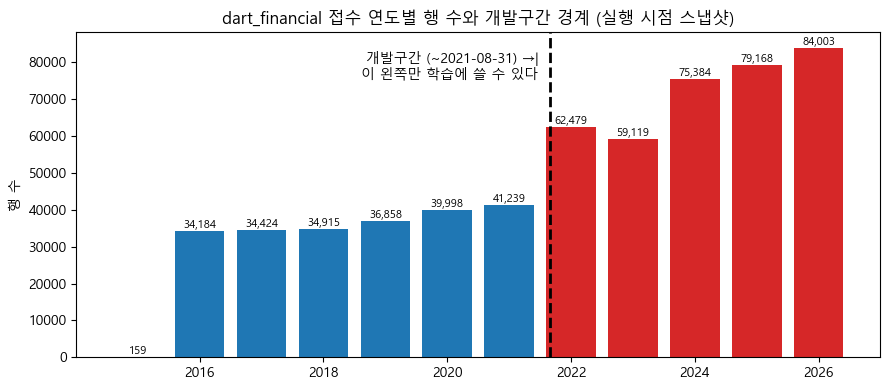

전체 581,930행 중 개발구간(접수일 ≤ 2021-08-31) 행 수 = 220,750행
→ 세션 시작 시점엔 0행이었다. FY2010~2020 추가 수집(이슈 #60)이 채워지는 중이라 220,750행으로 늘었다
⚠️ 이 수치는 실행 시점의 스냅샷이다 — 수집 세션이 지금도 같은 DB 에 쓰고 있다


In [2]:
# 접수 연도별 분포와 홀드아웃 경계를 겹쳐 본다
with ro_conn() as conn:
    dist = pd.read_sql_query(
        "SELECT CAST(substr(rcept_dt,1,4) AS INTEGER) AS 접수연도, COUNT(*) AS 행수 "
        "FROM dart_financial GROUP BY 접수연도 ORDER BY 접수연도", conn)
    in_dev = conn.execute(
        "SELECT COUNT(*) FROM dart_financial WHERE rcept_dt <= '20210831'").fetchone()[0]
    total = conn.execute("SELECT COUNT(*) FROM dart_financial").fetchone()[0]

boundary = 2021 + 8 / 12   # 2021-08-31 이 2021년의 2/3 지점
fig, ax = plt.subplots(figsize=(9, 4))
colors = ["tab:blue" if y <= 2021 else "#d62728" for y in dist["접수연도"]]
bars = ax.bar(dist["접수연도"], dist["행수"], color=colors)
ax.axvline(boundary, color="black", lw=2, ls="--")
ax.text(boundary - 0.2, dist["행수"].max() * 0.9,
        "개발구간 (~2021-08-31) →|\n이 왼쪽만 학습에 쓸 수 있다",
        ha="right", color="black", fontsize=10)
for b, v in zip(bars, dist["행수"]):
    ax.text(b.get_x() + b.get_width() / 2, v, f"{v:,}", ha="center", va="bottom", fontsize=8)
ax.set_title("dart_financial 접수 연도별 행 수와 개발구간 경계 (실행 시점 스냅샷)")
ax.set_ylabel("행 수")
plt.tight_layout(); plt.show()

print(f"전체 {total:,}행 중 개발구간(접수일 ≤ 2021-08-31) 행 수 = {in_dev:,}행")
if in_dev == 0:
    print("→ 개발구간 학습에 쓸 재무가 0건 — 이슈 #60 (FY2010~2020 추가 수집으로 해소 예정)")
else:
    print(f"→ 세션 시작 시점엔 0행이었다. FY2010~2020 추가 수집(이슈 #60)이 채워지는 중이라 {in_dev:,}행으로 늘었다")
print("⚠️ 이 수치는 실행 시점의 스냅샷이다 — 수집 세션이 지금도 같은 DB 에 쓰고 있다")

## 3. 수정주가 — 액면분할이 데이터에 그대로 있다 (이슈 #51)

KRX 는 수정주가를 주지 않습니다(원주가만). 삼성전자는 2018-05-04 에 50:1 액면분할을
했는데, 조정 없이 종가를 이으면 하루에 -98% 가 됩니다. Kronos 는 캔들 자체를 입력으로
쓰므로 이 갭을 **실제 폭락 패턴으로 학습**하게 됩니다 — 수정주가가 전제 조건입니다.

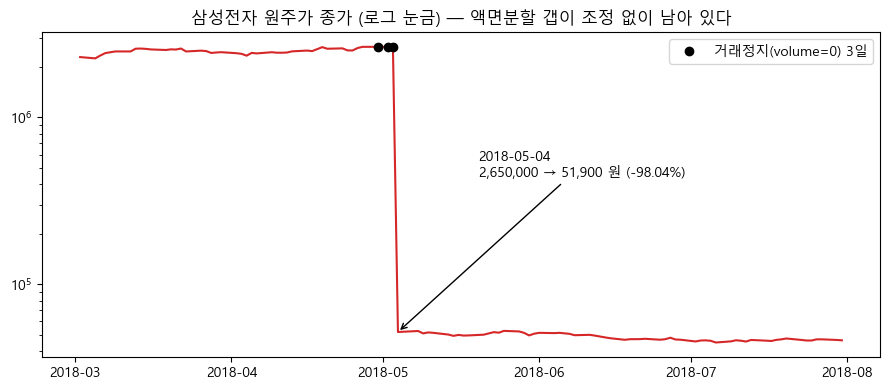

분할 갭 실측: 2,650,000 → 51,900 원 = -98.04%
→ 수정주가 없이 수익률·캔들을 만들면 안 된다. 조정 소스(FinanceDataReader, MIT)는 다음 수집 세션에서 검증


In [3]:
# 삼성전자 분할 전후 실측 — 갭과 거래정지가 데이터에 그대로 남아 있다
with ro_conn() as conn:
    ss = pd.read_sql_query(
        "SELECT bas_dd, close, volume FROM daily_price "
        "WHERE code = '005930' AND bas_dd BETWEEN '20180301' AND '20180731' "
        "ORDER BY bas_dd", conn)
ss["date"] = pd.to_datetime(ss["bas_dd"])

gap_prev = ss.loc[ss["bas_dd"] == "20180503", "close"].iloc[0]
gap_next = ss.loc[ss["bas_dd"] == "20180504", "close"].iloc[0]
drop = gap_next / gap_prev - 1

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ss["date"], ss["close"], color="tab:red")
ax.set_yscale("log")
ax.annotate(f"2018-05-04\n{gap_prev:,.0f} → {gap_next:,.0f} 원 ({drop:+.2%})",
            xy=(pd.Timestamp("2018-05-04"), gap_next),
            xytext=(pd.Timestamp("2018-05-20"), gap_prev / 6),
            arrowprops=dict(arrowstyle="->"), fontsize=10)
halt = ss[ss["volume"] == 0]
ax.scatter(halt["date"], halt["close"], color="black", zorder=3,
           label=f"거래정지(volume=0) {len(halt)}일")
ax.set_title("삼성전자 원주가 종가 (로그 눈금) — 액면분할 갭이 조정 없이 남아 있다")
ax.legend(); plt.tight_layout(); plt.show()

print(f"분할 갭 실측: {gap_prev:,.0f} → {gap_next:,.0f} 원 = {drop:+.2%}")
print("→ 수정주가 없이 수익률·캔들을 만들면 안 된다. 조정 소스(FinanceDataReader, MIT)는 다음 수집 세션에서 검증")

## 4. 연속 격자 — Kronos 창(512봉)을 만들 수 있는 종목은 얼마나 되나

Kronos 입력은 결측 없는 연속 캔들 시퀀스입니다. 종목마다 상장일·상장폐지가 달라
행 수가 제각각이고, 거래정지(volume=0)도 있습니다. **행이 몇 개인 종목이 얼마나
되는지**부터 재야 창 설계를 할 수 있습니다.

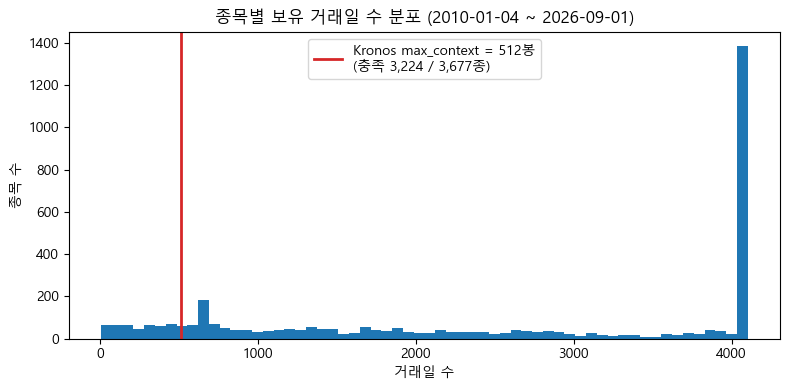

전체 3,677종 중 512봉 이상 보유 = 3,224종 (87.7%)
거래정지일(volume=0)이 하루라도 있는 종목 = 2,136종
→ 창 설계 규칙: ① 상장 512일 미만 종목은 Kronos 대상에서 제외(LightGBM 은 가능)
   ② 정지 구간이 창에 들어오면 그 창은 버린다 — 가격이 멎어 있어 패턴이 왜곡된다


In [4]:
# 종목별 거래일 수 분포 — 512봉 창이 나오는 종목 수를 센다
with ro_conn() as conn:
    per_code = pd.read_sql_query(
        "SELECT code, COUNT(*) AS 거래일수, SUM(volume = 0) AS 정지일수 "
        "FROM daily_price GROUP BY code", conn)

enough = (per_code["거래일수"] >= 512).sum()
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(per_code["거래일수"], bins=60, color="tab:blue")
ax.axvline(512, color="tab:red", lw=2, label=f"Kronos max_context = 512봉\n(충족 {enough:,} / {len(per_code):,}종)")
ax.set_title("종목별 보유 거래일 수 분포 (2010-01-04 ~ 2026-09-01)")
ax.set_xlabel("거래일 수"); ax.set_ylabel("종목 수"); ax.legend()
plt.tight_layout(); plt.show()

print(f"전체 {len(per_code):,}종 중 512봉 이상 보유 = {enough:,}종 ({enough/len(per_code):.1%})")
print(f"거래정지일(volume=0)이 하루라도 있는 종목 = {(per_code['정지일수'] > 0).sum():,}종")
print("→ 창 설계 규칙: ① 상장 512일 미만 종목은 Kronos 대상에서 제외(LightGBM 은 가능)")
print("   ② 정지 구간이 창에 들어오면 그 창은 버린다 — 가격이 멎어 있어 패턴이 왜곡된다")

## 5. 분수 차분 — 1차 차분과 원계열 사이 (팀장 딥리서치 → 채택)

수익률(1차 차분)은 정상성을 얻는 대신 **장기 기억을 전부 버립니다**. 분수 차분은
차수 d 를 0~1 사이 실수로 두어, ADF 검정(수업에서 배운 정상성 검정)을 통과하는
**최소 d** 만큼만 차분합니다 — 정상성과 기억 보존의 절충점입니다.

라이브러리는 라이선스가 불명확해 **가중치 공식을 직접 구현**합니다(십수 줄).
분할 갭(3절)이 섞이면 데모가 오염되므로, 분할 이후 구간(2018-05-04~)만 씁니다.

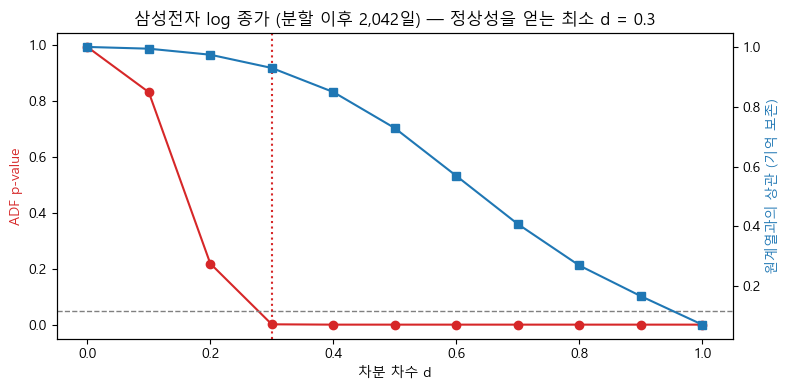

  d        ADF_p    원계열상관
0.0 9.937032e-01 1.000000
0.1 8.318239e-01 0.994153
0.2 2.187584e-01 0.973997
0.3 1.131602e-03 0.929690
0.4 2.653787e-09 0.849318
0.5 3.734384e-19 0.728696
0.6 1.509807e-28 0.568972
0.7 0.000000e+00 0.407940
0.8 0.000000e+00 0.269366
0.9 0.000000e+00 0.166836
1.0 0.000000e+00 0.071418

→ d=1(수익률)의 원계열 상관 0.071 대비, d*=0.3 는 상관 0.930 를 지키면서 정상성 확보
→ 채택: 가격·거시 수준(level) 계열의 파생 피처로 분수 차분 칸을 추가한다 (수익률 칸을 대체하지 않고 병행)


In [5]:
# 분수 차분 직접 구현 — 고정 창 방식 (López de Prado)
from statsmodels.tsa.stattools import adfuller

def frac_diff_weights(d: float, threshold: float = 1e-4) -> np.ndarray:
    # w_0 = 1, w_k = -w_{k-1} * (d - k + 1) / k — 절댓값이 threshold 밑이면 자른다
    w = [1.0]
    k = 1
    while True:
        wk = -w[-1] * (d - k + 1) / k
        if abs(wk) < threshold:
            break
        w.append(wk)
        k += 1
    return np.array(w)

def frac_diff(series: pd.Series, d: float) -> pd.Series:
    w = frac_diff_weights(d)[::-1]          # 오래된 것부터 곱하도록 뒤집는다
    n = len(w)
    values = series.to_numpy(dtype=float)
    out = np.full(len(series), np.nan)
    for i in range(n - 1, len(series)):
        out[i] = w @ values[i - n + 1 : i + 1]
    return pd.Series(out, index=series.index)

with ro_conn() as conn:
    px = pd.read_sql_query(
        "SELECT bas_dd, close FROM daily_price "
        "WHERE code = '005930' AND bas_dd >= '20180504' ORDER BY bas_dd", conn)
px["date"] = pd.to_datetime(px["bas_dd"])
log_close = pd.Series(np.log(px["close"].to_numpy()), index=px["date"])

rows = []
for d in np.arange(0.0, 1.01, 0.1):
    fd = frac_diff(log_close, d).dropna()
    pval = adfuller(fd, maxlag=1, regression="c")[1]
    corr = fd.corr(log_close.loc[fd.index])   # 원계열과의 상관 = 기억 보존 정도
    rows.append({"d": round(d, 1), "ADF_p": pval, "원계열상관": corr})
sweep = pd.DataFrame(rows)
d_star = sweep.loc[sweep["ADF_p"] < 0.05, "d"].min()

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(sweep["d"], sweep["ADF_p"], "o-", color="tab:red", label="ADF p-value")
ax1.axhline(0.05, color="gray", ls="--", lw=1)
ax1.axvline(d_star, color="tab:red", ls=":", lw=1.5)
ax1.set_xlabel("차분 차수 d"); ax1.set_ylabel("ADF p-value", color="tab:red")
ax2 = ax1.twinx()
ax2.plot(sweep["d"], sweep["원계열상관"], "s-", color="tab:blue", label="원계열과의 상관")
ax2.set_ylabel("원계열과의 상관 (기억 보존)", color="tab:blue")
ax1.set_title(f"삼성전자 log 종가 (분할 이후 {len(log_close):,}일) — 정상성을 얻는 최소 d = {d_star}")
plt.tight_layout(); plt.show()

print(sweep.to_string(index=False))
print(f"\n→ d=1(수익률)의 원계열 상관 {sweep.iloc[-1]['원계열상관']:.3f} 대비, "
      f"d*={d_star} 는 상관 {sweep.loc[sweep['d'] == d_star, '원계열상관'].iloc[0]:.3f} 를 지키면서 정상성 확보")
print("→ 채택: 가격·거시 수준(level) 계열의 파생 피처로 분수 차분 칸을 추가한다 (수익률 칸을 대체하지 않고 병행)")

## 6. 접수일 as-of join — 미래 누출이 실제로 얼마나 생기나

같은 재무를 **결산기준일**로 붙였을 때와 **접수일**로 붙였을 때를 비교합니다.
검증식이 항등식이 되지 않도록, 두 방식 모두에 같은 누출 검사
("붙은 값의 접수일이 그 거래일보다 미래인 행 수")를 적용합니다 —
접수일 join 은 0 이어야 하고, 결산기 join 은 0 이 **아니어야** 검사가 유효합니다.

덧붙여 실측에서 **계정 이름도, 계정코드도 연도마다 흔들린다**는 것이 확인됐습니다.
삼성전자 손익계산서의 당기순이익은 FY2023 까지 `당기순이익(손실)`, FY2024 부터
`당기순이익` 이고, `account_id` 는 FY2018 까지 `ifrs_ProfitLoss`, FY2019 부터
`ifrs-full_ProfitLoss` 입니다 (taxonomy 개정). 그래서 계정 매칭은 원문 이름의
완전 일치가 아니라 **taxonomy 접두사를 벗긴 계정코드**로 해야 합니다 —
아래 쿼리가 suffix 매칭을 쓰는 이유입니다.

붙일 재무 (연결 손익계산서 당기순이익 — 계정코드 suffix 'ProfitLoss' 매칭):
 bsns_year rcept_dt           account_id account_nm  thstrm_amount
      2015 20160330      ifrs_ProfitLoss  당기순이익(손실)   1.906014e+13
      2016 20170331      ifrs_ProfitLoss  당기순이익(손실)   2.272609e+13
      2017 20180402      ifrs_ProfitLoss  당기순이익(손실)   4.218675e+13
      2018 20190401      ifrs_ProfitLoss  당기순이익(손실)   4.434486e+13
      2019 20200330 ifrs-full_ProfitLoss  당기순이익(손실)   2.173886e+13
      2020 20210309 ifrs-full_ProfitLoss  당기순이익(손실)   2.640783e+13
      2021 20220308 ifrs-full_ProfitLoss  당기순이익(손실)   3.990745e+13
      2022 20230307 ifrs-full_ProfitLoss  당기순이익(손실)   5.565408e+13
      2023 20240312 ifrs-full_ProfitLoss  당기순이익(손실)   1.548710e+13
      2024 20250311 ifrs-full_ProfitLoss      당기순이익   3.445135e+13
      2025 20260310 ifrs-full_ProfitLoss      당기순이익   4.520680e+13

누출 검사 — 붙은 값의 접수일이 거래일보다 미래인 행 수
  방식 A (접수일 join)  : 0행  ← 0 이어야 정상
  방식 B (결산기 join)  : 560행  ← 0 이 아니어야 검사가 유효 (항등식 방지)


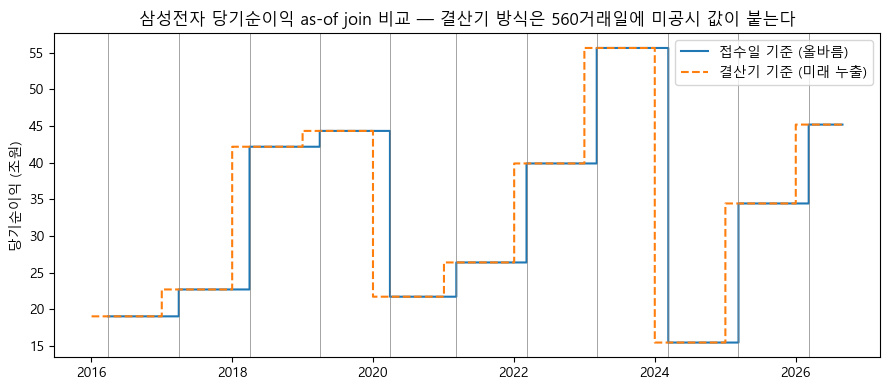

In [6]:
# 삼성전자 연결 당기순이익을 두 방식으로 붙여 누출 행 수를 비교한다
with ro_conn() as conn:
    fin = pd.read_sql_query(
        "SELECT bsns_year, rcept_dt, account_id, account_nm, thstrm_amount "
        "FROM dart_financial "
        "WHERE stock_code = '005930' AND sj_div = 'IS' AND fs_div = 'CFS' "
        "AND account_detail = '-' AND account_id LIKE '%ProfitLoss' "
        "ORDER BY bsns_year", conn)
    days = pd.read_sql_query(
        "SELECT bas_dd FROM daily_price WHERE code = '005930' "
        "AND bas_dd >= '20160101' ORDER BY bas_dd", conn)

print("붙일 재무 (연결 손익계산서 당기순이익 — 계정코드 suffix 'ProfitLoss' 매칭):")
print(fin.to_string(index=False))

fin["접수일"] = pd.to_datetime(fin["rcept_dt"])
fin["결산기준일"] = pd.to_datetime((fin["bsns_year"].astype(int)).astype(str) + "1231")
days["date"] = pd.to_datetime(days["bas_dd"])

# 방식 A: 접수일 기준 as-of (뒤로만 본다 — 그 날까지 세상에 나온 최신 보고서)
a = pd.merge_asof(days.sort_values("date"), fin.sort_values("접수일"),
                  left_on="date", right_on="접수일", direction="backward")
# 방식 B: 결산기준일 기준 as-of (잘못된 방식 — 아직 공시 안 된 값이 붙는다)
b = pd.merge_asof(days.sort_values("date"), fin.sort_values("결산기준일"),
                  left_on="date", right_on="결산기준일", direction="backward")

leak_a = int((a["접수일"] > a["date"]).sum())
leak_b = int((b["접수일"] > b["date"]).sum())
print(f"\n누출 검사 — 붙은 값의 접수일이 거래일보다 미래인 행 수")
print(f"  방식 A (접수일 join)  : {leak_a}행  ← 0 이어야 정상")
print(f"  방식 B (결산기 join)  : {leak_b}행  ← 0 이 아니어야 검사가 유효 (항등식 방지)")
assert leak_a == 0 and leak_b > 0

fig, ax = plt.subplots(figsize=(9, 4))
ax.step(a["date"], a["thstrm_amount"] / 1e12, where="post", label="접수일 기준 (올바름)")
ax.step(b["date"], b["thstrm_amount"] / 1e12, where="post", ls="--", label="결산기 기준 (미래 누출)")
for _, r in fin.iterrows():
    ax.axvline(r["접수일"], color="gray", lw=0.5)
ax.set_title(f"삼성전자 당기순이익 as-of join 비교 — 결산기 방식은 {leak_b}거래일에 미공시 값이 붙는다")
ax.set_ylabel("당기순이익 (조원)"); ax.legend()
plt.tight_layout(); plt.show()

## 7. 전처리 파이프라인 설계 (요약)

위 실측을 근거로 한 설계입니다. 상세 단계·유스케이스는
`docs/전처리/version1.0/전처리-설계-명세서.md` 에 mermaid 로 그렸습니다.

| 단계 | 내용 | 근거 |
|---|---|---|
| ① 수정주가 | FinanceDataReader(MIT) 등 조정 소스 검증 후 조정계수 적용 | 3절 — 분할 갭 -98% |
| ② 격자 정리 | 종목×거래일 격자. 정지 구간(volume=0)이 든 Kronos 창은 폐기 | 4절 |
| ③ 결측 보간 | 시계열 특성 고려 보간(수업 05 규칙). 상장 전 구간은 만들지 않는다 | 4절 |
| ④ 재무 결합 | **접수일 기준 merge_asof** + 누출 검사(음성 대조군 포함) 상시 실행. 계정은 taxonomy 접두사를 벗긴 `account_id` 로 매칭 (이름·코드가 연도마다 흔들림) | 6절 |
| ⑤ 거시 결합 | ECOS 발표 시차(일별 +1일 · 기준금리 +1개월 · 물가/경기 +2개월) 반영 as-of | 실측 시차표 |
| ⑥ 파생 | lag 는 `shift(+)`, 타깃은 `shift(-)`, 분수 차분 칸 병행 추가 | 5절 |
| ⑦ 분할 | 시간 순서 분할. 홀드아웃(2021-09-01~)은 봉인 유지 | 2절 |

### 막힌 것 (해소 경로)

- **개발구간 재무 부족** → 이슈 #60 (수집 세션이 FY2010~2020 추가 수집 중 — 이 노트북
  실행 시점엔 이미 일부 채워졌다 · DEV_END 재논의 열려 있음)
- **수정주가 소스 미확정** → 다음 수집 세션에서 FDR 검증 (#51)

### 못 잰 것

- Kronos fine-tune 의 VRAM 요구량 — Colab 연결 후 실측 예정
- 분수 차분 d* 의 종목별 분포 — 전 종목 스윕은 수정주가 확보 후 (원주가로는 분할 갭 오염)